In [ ]:
#AtliQ Hotels Data Analysis Project
#==> 1. Data Import and Data Exploration

In [ ]:
Datasets
We have 5 csv file

dim_date.csv
dim_hotels.csv
dim_rooms.csv
fact_aggregated_bookings
fact_bookings.csv

In [102]:
import os
os.getcwd()


'C:\\Users\\madhvi\\Downloads\\hospitality data set\\datasets'

In [103]:

import os
os.chdir('C:/Users/madhvi/Downloads/hospitality data set/datasets')



In [104]:
import pandas as pd


In [ ]:
#Read bookings data in a datagram

In [111]:
pd.read_csv('fact_bookings.csv')
pd.read_csv('dim_date.csv')
pd.read_csv('dim_hotels.csv')
pd.read_csv('dim_rooms.csv')
pd.read_csv('fact_aggregated_bookings.csv')

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0
...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0
9196,16559,31-Jul-22,RT4,13,18.0
9197,17558,31-Jul-22,RT4,3,6.0
9198,19563,31-Jul-22,RT4,3,6.0


In [2]:
#Explore bookings data

In [110]:
df_bookings = pd.read_csv('fact_bookings.csv')
df_bookings.head(4)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640


In [90]:
df_bookings.shape

(134590, 12)

In [12]:
df_bookings.room_category.unique()

array(['RT1', 'RT2', 'RT3', 'RT4'], dtype=object)

In [13]:
df_bookings.booking_platform.unique()

array(['direct online', 'others', 'logtrip', 'tripster', 'makeyourtrip',
       'journey', 'direct offline'], dtype=object)

In [15]:
df_bookings.booking_platform.value_counts()

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

<Axes: xlabel='booking_platform'>

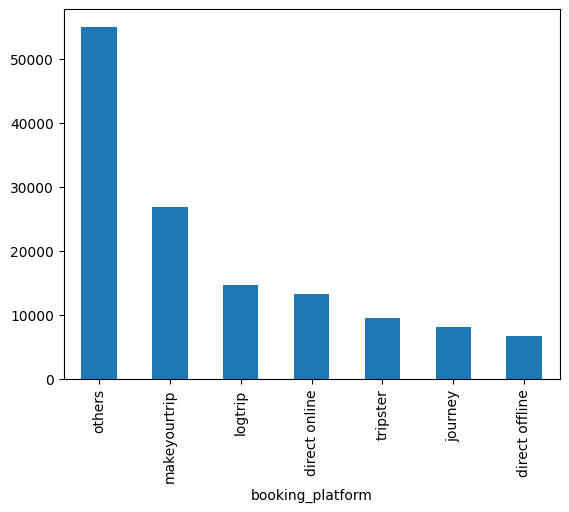

In [17]:
df_bookings.booking_platform.value_counts().plot(kind="bar")

<Axes: ylabel='booking_platform'>

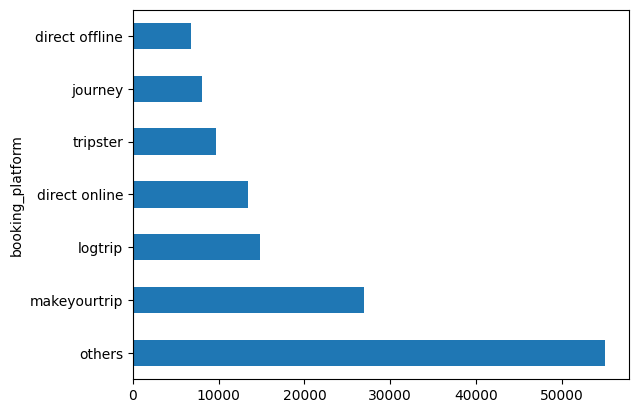

In [19]:
df_bookings.booking_platform.value_counts().plot(kind="barh")

In [112]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [113]:
df_bookings.revenue_generated.min(),df_bookings.revenue_generated.max()

(6500, 28560000)

In [ ]:
#Read rest of the files

In [114]:
df_date = pd.read_csv('dim_date.csv')
df_hotels = pd.read_csv('dim_hotels.csv')
df_rooms = pd.read_csv('dim_rooms.csv')
df_agg_bookings = pd.read_csv('fact_aggregated_bookings.csv')


In [92]:
df_hotels.shape

(25, 4)

In [115]:
df_hotels.head(4)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi


In [26]:
df_hotels.category.value_counts()

category
Luxury      16
Business     9
Name: count, dtype: int64

<Axes: xlabel='city'>

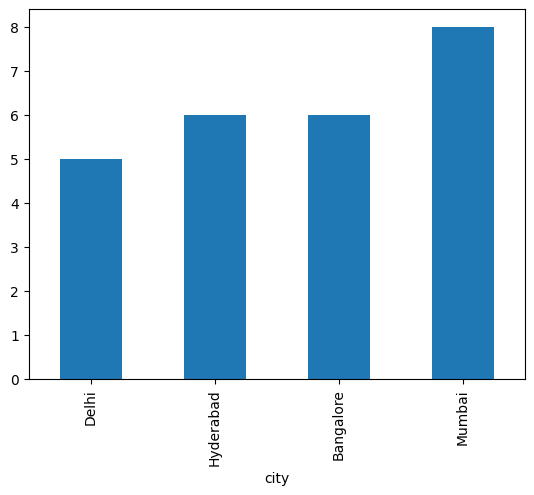

In [32]:
df_hotels.city.value_counts().sort_values().plot(kind="bar")


In [ ]:
#> 2. Data Cleaning

In [33]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [36]:

df_bookings[df_bookings.no_guests<=0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.0,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.0,RT3,direct offline,5.0,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.0,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.0,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.0,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


In [ ]:
#(1) Clean invalid guests

In [38]:
df_bookings=df_bookings[df_bookings.no_guests>0]
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [ ]:
##As you can see above, number of guests having less than zero value represents data error. We can ignore these records.

In [39]:
df_bookings.shape

(134578, 12)

In [ ]:
#(2) Outlier removal in revenue generated

In [40]:
df_bookings.revenue_generated.min(),df_bookings.revenue_generated.max()

(6500, 28560000)

In [118]:
avg = df_bookings.revenue_generated.mean()

In [119]:
std = df_bookings.revenue_generated.std()

In [120]:
avg ,std = df_bookings.revenue_generated.mean(), df_bookings.revenue_generated.std()
avg,std


(15378.05412734973, 93036.03867095453)

In [121]:
higher_limit = avg + 3*std
higher_limit

294486.17014021333

In [122]:
lower_limit = avg - 3*std
lower_limit

-263730.06188551383

In [123]:
df_bookings[df_bookings.revenue_generated>higher_limit]


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-22,1/5/2022,4/5/2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-22,28-07-22,29-07-22,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


In [124]:
 df_bookings=df_bookings[df_bookings.revenue_generated<higher_limit]


In [71]:
df_bookings.shape

(134573, 12)

In [125]:
 df_bookings.revenue_realized.describe()

count    134585.000000
mean      12696.095025
std        6928.058192
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

In [74]:
higher_limit =  df_bookings.revenue_realized.mean() + 3*  df_bookings.revenue_realized.std()

In [75]:
higher_limit

33479.358661845814

In [76]:
 df_bookings=df_bookings[df_bookings.revenue_realized>higher_limit]

In [127]:
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [126]:
df_rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [93]:
df_bookings[df_bookings.room_category == "RT4"]


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
47,May012216558RT41,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT4,logtrip,NaN,Cancelled,26600,10640
48,May012216558RT42,16558,27-04-22,1/5/2022,2/5/2022,1.0,RT4,tripster,NaN,Checked Out,26600,26600
49,May012216558RT43,16558,29-04-22,1/5/2022,4/5/2022,2.0,RT4,direct offline,NaN,Cancelled,26600,10640
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
138,May012216559RT42,16559,11/4/2022,1/5/2022,3/5/2022,2.0,RT4,direct offline,NaN,Cancelled,32300,12920
...,...,...,...,...,...,...,...,...,...,...,...,...
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [94]:
df_bookings[df_bookings.room_category == "RT4"].revenue_realized.describe()

count    16073.000000
mean     23440.103652
std       9048.865206
min       7600.000000
25%      19000.000000
50%      26600.000000
75%      32300.000000
max      45220.000000
Name: revenue_realized, dtype: float64

In [ ]:
#One observation we can have in above dataframe is that all rooms are RT4 which means presidential suit. Now since RT4 is a luxurious room it is likely their rent will be higher. To make a fair analysis, we need to do data analysis only on RT4 room types

In [95]:
23440+3*9048

50584

In [ ]:
#Here higher limit comes to be 50583 and in our dataframe above we can see that max value for revenue realized is 45220. Hence we can conclude that there is no outlier and we don't need to do any data cleaning on this particular column

In [98]:
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                3
room_category            0
booking_platform         0
ratings_given        77907
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

In [ ]:
#Total values in our dataframe is 134576. Out of that 77899 rows has null rating. Since there are many rows with null rating, we should not filter these values. Also we should not replace this rating with a median or mean rating etc

In [ ]:
#==> 3. Data Transformation



In [48]:
df_agg_bookings['occ_pct'] = df_agg_bookings.apply(lambda row: row['successful_bookings']/row['capacity'], axis=1)

In [49]:
df_agg_bookings["oct_pct"]= df_agg_bookings["successful_bookings"]/df_agg_bookings["capacity"]

In [128]:
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0


In [ ]:
#Convert it to a percentage value

In [53]:
def foo():
    pass


df_agg_bookings["oct_pct"]= df_agg_bookings["oct_pct"].apply(lambda x:round(x*100,2) )
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,oct_pct
0,16559,1-May-22,RT1,25,30.0,0.833333,83.33
1,19562,1-May-22,RT1,28,30.0,0.933333,93.33
2,19563,1-May-22,RT1,23,30.0,0.766667,76.67


In [129]:
df_bookings.head()


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100


In [55]:
df_agg_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          9200 non-null   int64  
 1   check_in_date        9200 non-null   object 
 2   room_category        9200 non-null   object 
 3   successful_bookings  9200 non-null   int64  
 4   capacity             9198 non-null   float64
 5   occ_pct              9198 non-null   float64
 6   oct_pct              9198 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 503.2+ KB


In [ ]:
#There are various types of data transformations that you may have to perform based on the need. Few examples of data transformations are,

#Creating new columns
#Normalization
#Merging data
#Aggregation

In [130]:
df_agg_bookings.groupby("room_category")["oct_pct"].mean()

room_category
RT1    582242.471715
RT2    580402.782609
RT3    580282.130435
RT4    593004.608696
Name: oct_pct, dtype: float64

In [ ]:
# 4. Insights Generation

In [131]:

df_rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [68]:
df = pd.merge(df_agg_bookings, df_rooms, left_on="room_category", right_on="room_id")
df.head(4)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,oct_pct,room_id,room_class
0,16559,1-May-22,RT1,25,30.0,0.833333,83.33,RT1,Standard
1,19562,1-May-22,RT1,28,30.0,0.933333,93.33,RT1,Standard
2,19563,1-May-22,RT1,23,30.0,0.766667,76.67,RT1,Standard
3,17558,1-May-22,RT1,30,19.0,1.578947,157.89,RT1,Standard


In [69]:
df.groupby("room_class")["oct_pct"].mean()

room_class
Elite           58.040278
Premium         58.028213
Presidential    59.300461
Standard        58.224247
Name: oct_pct, dtype: float64

In [ ]:
I don't understand RT1, RT2 etc. Print room categories such as Standard, Premium, Elite etc along with average occupancy percentage

In [138]:
df.drop("room_id",axis=1, inplace=True)
df.head(4)

,property_id,check_in_date,room_category,successful_bookings,capacity,oct_pct,room_class
0,16559,1-May-22,RT1,25,30.0,833300.0,Standard
1,19562,1-May-22,RT1,28,30.0,933300.0,Standard
2,19563,1-May-22,RT1,23,30.0,766700.0,Standard
3,17558,1-May-22,RT1,30,19.0,1578900.0,Standard


In [140]:
df_hotels.head(3)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi


In [141]:
df=pd.merge(df,df_hotels,on="property_id")
df

,property_id,check_in_date,room_category,successful_bookings,capacity,oct_pct,room_class,property_name,category,city
0,16559,1-May-22,RT1,25,30.0,833300.0,Standard,Atliq Exotica,Luxury,Mumbai
1,16559,2-May-22,RT1,20,30.0,666700.0,Standard,Atliq Exotica,Luxury,Mumbai
2,16559,3-May-22,RT1,17,30.0,566700.0,Standard,Atliq Exotica,Luxury,Mumbai
3,16559,4-May-22,RT1,21,30.0,700000.0,Standard,Atliq Exotica,Luxury,Mumbai
4,16559,5-May-22,RT1,16,30.0,533300.0,Standard,Atliq Exotica,Luxury,Mumbai
...,...,...,...,...,...,...,...,...,...,...
9195,18560,27-Jul-22,RT4,6,15.0,400000.0,Presidential,Atliq City,Business,Hyderabad
9196,18560,28-Jul-22,RT4,9,15.0,600000.0,Presidential,Atliq City,Business,Hyderabad
9197,18560,29-Jul-22,RT4,8,15.0,533300.0,Presidential,Atliq City,Business,Hyderabad
9198,18560,30-Jul-22,RT4,9,15.0,600000.0,Presidential,Atliq City,Business,Hyderabad


In [148]:
df.groupby("city")["oct_pct"].mean()

city
Bangalore    565942.074275
Delhi        616064.673913
Hyderabad    581446.512681
Mumbai       579363.052345
Name: oct_pct, dtype: float64

<Axes: xlabel='city'>

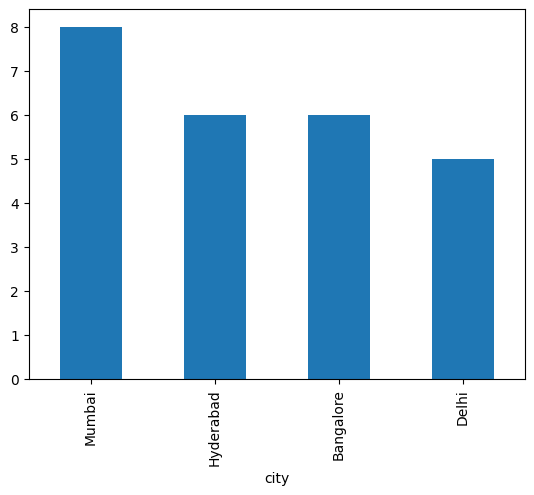

In [150]:
df_hotels.city.value_counts().plot(kind="bar")

In [152]:
df.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,oct_pct,room_class,property_name,category,city
0,16559,1-May-22,RT1,25,30.0,833300.0,Standard,Atliq Exotica,Luxury,Mumbai
1,16559,2-May-22,RT1,20,30.0,666700.0,Standard,Atliq Exotica,Luxury,Mumbai
2,16559,3-May-22,RT1,17,30.0,566700.0,Standard,Atliq Exotica,Luxury,Mumbai


In [153]:
df_date

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday
...,...,...,...,...
87,27-Jul-22,Jul 22,W 31,weekeday
88,28-Jul-22,Jul 22,W 31,weekeday
89,29-Jul-22,Jul 22,W 31,weekeday
90,30-Jul-22,Jul 22,W 31,weekend


In [90]:
# Convert both columns to datetime if necessary
df['check_in_date'] = pd.to_datetime(df['check_in_date'])
df_date['date'] = pd.to_datetime(df_date['date'])

# Merge the DataFrames
df = pd.merge(df, df_date, left_on="check_in_date", right_on="date")

# Display the first 3 rows
df.head(3)


,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,oct_pct,room_id,room_class,date_x,...,week no_x,day_type_x,date_y,mmm yy_y,week no_y,day_type_y,date,mmm yy,week no,day_type
0,16559,2022-05-01,RT1,25,30.0,0.833333,83.33,RT1,Standard,2022-05-01,...,W 19,weekend,2022-05-01,May 22,W 19,weekend,2022-05-01,May 22,W 19,weekend
1,19562,2022-05-01,RT1,28,30.0,0.933333,93.33,RT1,Standard,2022-05-01,...,W 19,weekend,2022-05-01,May 22,W 19,weekend,2022-05-01,May 22,W 19,weekend
2,19563,2022-05-01,RT1,23,30.0,0.766667,76.67,RT1,Standard,2022-05-01,...,W 19,weekend,2022-05-01,May 22,W 19,weekend,2022-05-01,May 22,W 19,weekend


In [157]:
df.groupby("day_type")["oct_pct"].mean().round(2)

day_type
weekeday    509037.80
weekend     723934.32
Name: oct_pct, dtype: float64

In [158]:
df_august = pd.read_csv("new_data_august.csv")

In [159]:
df_august.head(3)

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
0,16559,Atliq Exotica,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Atliq Bay,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Atliq Palace,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67


In [161]:
df_august.columns

Index(['property_id', 'property_name', 'category', 'city', 'room_category',
       'room_class', 'check_in_date', 'mmm yy', 'week no', 'day_type',
       'successful_bookings', 'capacity', 'occ%'],
      dtype='object')

df.columns

In [162]:
df_august.shape

(7, 13)

In [163]:
df.shape

(6500, 14)

In [164]:
latest_df = pd.concat([df, df_august], ignore_index = True, axis = 0)
latest_df.tail(10)

,property_id,check_in_date,room_category,successful_bookings,capacity,oct_pct,room_class,property_name,category,city,date,mmm yy,week no,day_type,occ%
6497,18560,31-Jul-22,RT2,34,40.0,850000.0,Elite,Atliq City,Business,Hyderabad,31-Jul-22,Jul 22,W 32,weekend,NaN
6498,18560,31-Jul-22,RT3,17,24.0,708300.0,Premium,Atliq City,Business,Hyderabad,31-Jul-22,Jul 22,W 32,weekend,NaN
6499,18560,31-Jul-22,RT4,12,15.0,800000.0,Presidential,Atliq City,Business,Hyderabad,31-Jul-22,Jul 22,W 32,weekend,NaN
6500,16559,01-Aug-22,RT1,30,30.0,NaN,Standard,Atliq Exotica,Luxury,Mumbai,NaN,Aug-22,W 32,weekeday,100.00
6501,19562,01-Aug-22,RT1,21,30.0,NaN,Standard,Atliq Bay,Luxury,Bangalore,NaN,Aug-22,W 32,weekeday,70.00
6502,19563,01-Aug-22,RT1,23,30.0,NaN,Standard,Atliq Palace,Business,Bangalore,NaN,Aug-22,W 32,weekeday,76.67
6503,19558,01-Aug-22,RT1,30,40.0,NaN,Standard,Atliq Grands,Luxury,Bangalore,NaN,Aug-22,W 32,weekeday,75.00
6504,19560,01-Aug-22,RT1,20,26.0,NaN,Standard,Atliq City,Business,Bangalore,NaN,Aug-22,W 32,weekeday,76.92
6505,17561,01-Aug-22,RT1,18,26.0,NaN,Standard,Atliq Blu,Luxury,Mumbai,NaN,Aug-22,W 32,weekeday,69.23
6506,17564,01-Aug-22,RT1,10,16.0,NaN,Standard,Atliq Seasons,Business,Mumbai,NaN,Aug-22,W 32,weekeday,62.50


In [165]:
latest_df.shape

(6507, 15)

In [81]:
df_bookings.head(4)


,booking_id,property_id,check_in_date,month,week_no,booking_platform,ratings_given,booking_status,revenue_generated
0,Jun012218561RT217,18561,01-Jun-22,Jun-22,W 23,direct offline,3,Checked Out,10800
1,Jun012216558RT11,16558,01-Jun-22,Jun-22,W 23,journey,3,Checked Out,10920
2,Jun012218561RT216,18561,01-Jun-22,Jun-22,W 23,others,5,Checked Out,10800
3,Jun012218561RT312,18561,01-Jun-22,Jun-22,W 23,others,5,Checked Out,14400


In [10]:
df_hotels.head(3)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi


In [131]:
df_bookings_all = pd.merge(df_bookings, df_hotels, on="property_id")
df_bookings_all.head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010,Atliq Grands,Luxury,Delhi
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
2,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi


In [132]:
df_bookings_all.groupby("city")["revenue_realized"].sum()

city
Bangalore    420397050
Delhi        294466018
Hyderabad    325232870
Mumbai       668608011
Name: revenue_realized, dtype: int64

In [171]:
df_date.head(3)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday


In [73]:
df_date["mmm yy"].unique()

array(['May 22', 'Jun 22', 'Jul 22'], dtype=object)

In [96]:
df_bookings_all.head(3)

,booking_id,property_id,check_in_date,month,week_no,booking_platform,ratings_given,booking_status,revenue_generated,property_name,category,city
0,Jun012218561RT217,18561,01-Jun-22,Jun-22,W 23,direct offline,3,Checked Out,10800,Atliq Blu,Luxury,Hyderabad
1,Jun012218561RT216,18561,01-Jun-22,Jun-22,W 23,others,5,Checked Out,10800,Atliq Blu,Luxury,Hyderabad
2,Jun012218561RT312,18561,01-Jun-22,Jun-22,W 23,others,5,Checked Out,14400,Atliq Blu,Luxury,Hyderabad


In [174]:
df_bookings.info

<bound method DataFrame.info of                booking_id  property_id booking_date check_in_date  \
0        May012216558RT11        16558     27-04-22      1/5/2022   
1        May012216558RT12        16558     30-04-22      1/5/2022   
2        May012216558RT13        16558     28-04-22      1/5/2022   
3        May012216558RT14        16558     28-04-22      1/5/2022   
4        May012216558RT15        16558     27-04-22      1/5/2022   
...                   ...          ...          ...           ...   
134585   Jul312217564RT46        17564     29-07-22      31-07-22   
134586   Jul312217564RT47        17564     30-07-22      31-07-22   
134587   Jul312217564RT48        17564     30-07-22      31-07-22   
134588   Jul312217564RT49        17564     29-07-22      31-07-22   
134589  Jul312217564RT410        17564     31-07-22      31-07-22   

       checkout_date  no_guests room_category booking_platform  ratings_given  \
0           2/5/2022       -3.0           RT1    direct on

In [91]:
df_date["date"] = pd.to_datetime(df_date["date"])
df_date.head()

,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
1,2022-05-02,May 22,W 19,weekeday
2,2022-05-03,May 22,W 19,weekeday
3,2022-05-04,May 22,W 19,weekeday
4,2022-05-05,May 22,W 19,weekeday


In [178]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      92 non-null     datetime64[ns]
 1   mmm yy    92 non-null     object        
 2   week no   92 non-null     object        
 3   day_type  92 non-null     object        
dtypes: datetime64[ns](1), object(3)
memory usage: 3.0+ KB


In [75]:
df_bookings_all = pd.merge(df_bookings, df_hotels, on="property_id")
df_bookings_all.head(3)

,booking_id,property_id,check_in_date,month,week_no,booking_platform,ratings_given,booking_status,revenue_generated,property_name,category,city
0,Jun012218561RT217,18561,01-Jun-22,Jun-22,W 23,direct offline,3,Checked Out,10800,Atliq Blu,Luxury,Hyderabad
1,Jun012218561RT216,18561,01-Jun-22,Jun-22,W 23,others,5,Checked Out,10800,Atliq Blu,Luxury,Hyderabad
2,Jun012218561RT312,18561,01-Jun-22,Jun-22,W 23,others,5,Checked Out,14400,Atliq Blu,Luxury,Hyderabad


In [79]:
df_bookings_all.property_name.unique()

array(['Atliq Blu', 'Atliq Grands', 'Atliq City', 'Atliq Seasons'],
      dtype=object)

In [133]:
df_bookings_all.groupby("property_name")["revenue_realized"].sum().round(2).sort_values()

property_name
Atliq Seasons     66125495
Atliq Grands     211523664
Atliq Bay        260025978
Atliq Blu        260855522
Atliq City       285811939
Atliq Palace     304081863
Atliq Exotica    320279488
Name: revenue_realized, dtype: int64

In [134]:
df_bookings_all.groupby("city")["ratings_given"].mean().round(2)

city
Bangalore    3.41
Delhi        3.78
Hyderabad    3.66
Mumbai       3.65
Name: ratings_given, dtype: float64

<Axes: ylabel='revenue_realized'>

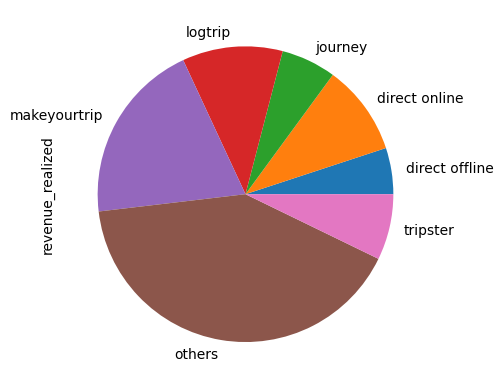

In [138]:
df_bookings_all.groupby("booking_platform")["revenue_realized"].sum().plot(kind="pie")